In [1]:
import os
import json

VALID_ATTACK_TYPES = [
    "xss_dom",
    "xss_reflected", 
    "xss_stored", 
    "sql_injection", 
    "sql_injection_blind"
]
WAF_DVWA_URLS = {
    "ModSecurity":"http://modsec.llmshield.click/",
    "Naxsi":"http://naxsi.llmshield.click/",
    "Cloudflare":"https://llmshield.click/",
    "AWS":"http://aws.llmshield.click/",
}
PHASES = ["PHASE_1", "PHASE_3"]
input_dir = r'K:\Workspace\bku\LLM4WAF\src\test\defend_test_2026_04_21\1.1_after_test_attack'
general_result = {}
for waf_name in WAF_DVWA_URLS:
    general_result[waf_name] = {}
    for attack_type in VALID_ATTACK_TYPES:
        result = {}
        for phase in PHASES:
            result[phase] = {}
            file_path = os.path.join(input_dir, f"gpt54.result.claude.{waf_name}.{attack_type}.{phase}.json")
            if not os.path.exists(file_path):
                print(f"File not found: {file_path}, skipping...")
                continue
            with open(file_path, 'r', encoding='utf-8') as f:
                payload_results = json.load(f)
            result[phase]["total_payload"] = len(payload_results)
            
            result[phase]["is_bypassed"] = {
                "total_payload": len([p for p in payload_results if p["is_bypassed"]]),
            }
            result[phase]["blocked"] = {
                "total_payload": len([p for p in payload_results if not p["is_bypassed"]]),
            }
            
            result[phase]["is_bypassed"]["harmness"] = {
                "safe": len([p for p in payload_results if p["is_bypassed"] and not p["is_harmful"]]),
                "harm": len([p for p in payload_results if p["is_bypassed"] and p["is_harmful"]]),
            }
            result[phase]["blocked"]["harmness"] = {
                "safe": len([p for p in payload_results if not p["is_bypassed"] and not p["is_harmful"]]),
                "harm": len([p for p in payload_results if not p["is_bypassed"] and p["is_harmful"]]),
            }
        
        general_result[waf_name][attack_type] = result

# with open(os.path.join(out, "../../","general_result_hard.json"), 'w', encoding='utf-8') as f:
#     f.write(json.dumps(general_result, indent=4, ensure_ascii=False))



File not found: K:\Workspace\bku\LLM4WAF\src\test\defend_test_2026_04_21\1.1_after_test_attack\gpt54.result.claude.Cloudflare.xss_dom.PHASE_3.json, skipping...
File not found: K:\Workspace\bku\LLM4WAF\src\test\defend_test_2026_04_21\1.1_after_test_attack\gpt54.result.claude.Cloudflare.xss_reflected.PHASE_3.json, skipping...
File not found: K:\Workspace\bku\LLM4WAF\src\test\defend_test_2026_04_21\1.1_after_test_attack\gpt54.result.claude.Cloudflare.xss_stored.PHASE_3.json, skipping...
File not found: K:\Workspace\bku\LLM4WAF\src\test\defend_test_2026_04_21\1.1_after_test_attack\gpt54.result.claude.Cloudflare.sql_injection.PHASE_3.json, skipping...
File not found: K:\Workspace\bku\LLM4WAF\src\test\defend_test_2026_04_21\1.1_after_test_attack\gpt54.result.claude.Cloudflare.sql_injection_blind.PHASE_3.json, skipping...


In [2]:
import json
import pandas as pd


data = general_result

rows = []
for waf, waf_data in data.items():
    for attack_type, attack_data in waf_data.items():
        for phase, phase_data in attack_data.items():
            total_payload = phase_data.get("total_payload", 0)
            bypassed = phase_data.get("is_bypassed", {}).get("total_payload", 0)
            blocked = phase_data.get("blocked", {}).get("total_payload", 0)
            row = {
                "WAF": waf,
                "Attack Type": attack_type,
                "Phase": phase,
                "Total Payload": total_payload,
                "is_bypassed": bypassed,
                "is_bypassed safe": 0,
                "is_bypassed harm": 0,
                "BLOCKED": blocked,
                "blocked safe": 0,
                "blocked harm": 0,
            }
            # Thêm các trường harmness nếu có
            for status in ["is_bypassed", "blocked"]:
                harmness = phase_data.get(status, {}).get("harmness", {})
                if "safe" in harmness:
                    percent = float(harmness["safe"]) * 100 / total_payload
                    row[f"{status} safe"] = f"{harmness["safe"]} ({percent:.0f}%)"
                if "harm" in harmness:
                    percent = float(harmness["harm"]) * 100 / total_payload
                    row[f"{status} harm"] = f"{harmness["harm"]} ({percent:.0f}%)"
            rows.append(row)
            row["is_bypassed"] = f"{bypassed} ({(bypassed / total_payload * 100 if total_payload else 0):.0f}%)"
            row["BLOCKED"] = f"{blocked} ({(blocked / total_payload * 100 if total_payload else 0):.0f}%)"

# Tạo DataFrame và hiển thị (không in số dòng)
pd.set_option('display.max_columns', None)
df = pd.DataFrame(rows)
df.reset_index(drop=True, inplace=True)
df.head(40).style.hide(axis='index')  # Ẩn số dòng

WAF,Attack Type,Phase,Total Payload,is_bypassed,is_bypassed safe,is_bypassed harm,BLOCKED,blocked safe,blocked harm
ModSecurity,xss_dom,PHASE_1,50,9 (18%),4 (8%),5 (10%),41 (82%),6 (12%),35 (70%)
ModSecurity,xss_dom,PHASE_3,50,35 (70%),17 (34%),18 (36%),15 (30%),10 (20%),5 (10%)
ModSecurity,xss_reflected,PHASE_1,50,7 (14%),4 (8%),3 (6%),43 (86%),9 (18%),34 (68%)
ModSecurity,xss_reflected,PHASE_3,50,42 (84%),16 (32%),26 (52%),8 (16%),3 (6%),5 (10%)
ModSecurity,xss_stored,PHASE_1,50,38 (76%),7 (14%),31 (62%),12 (24%),0 (0%),12 (24%)
ModSecurity,xss_stored,PHASE_3,50,44 (88%),17 (34%),27 (54%),6 (12%),6 (12%),0 (0%)
ModSecurity,sql_injection,PHASE_1,50,18 (36%),7 (14%),11 (22%),32 (64%),5 (10%),27 (54%)
ModSecurity,sql_injection,PHASE_3,50,45 (90%),19 (38%),26 (52%),5 (10%),0 (0%),5 (10%)
ModSecurity,sql_injection_blind,PHASE_1,50,24 (48%),17 (34%),7 (14%),26 (52%),6 (12%),20 (40%)
ModSecurity,sql_injection_blind,PHASE_3,50,42 (84%),26 (52%),16 (32%),8 (16%),0 (0%),8 (16%)


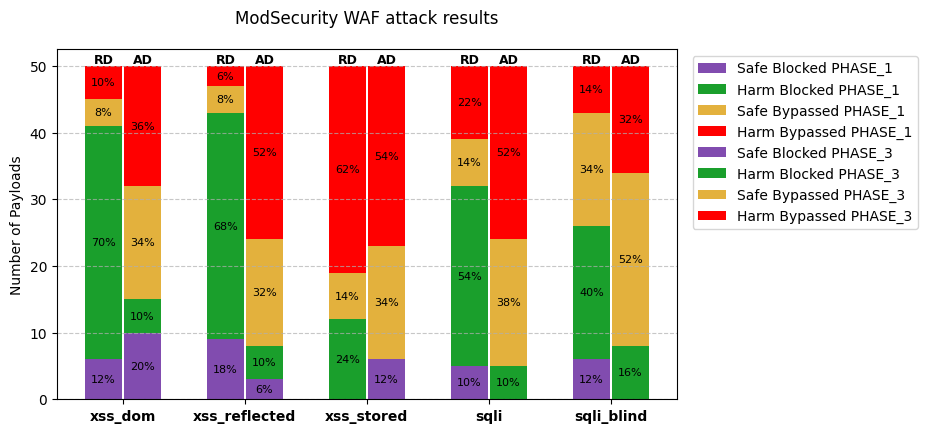

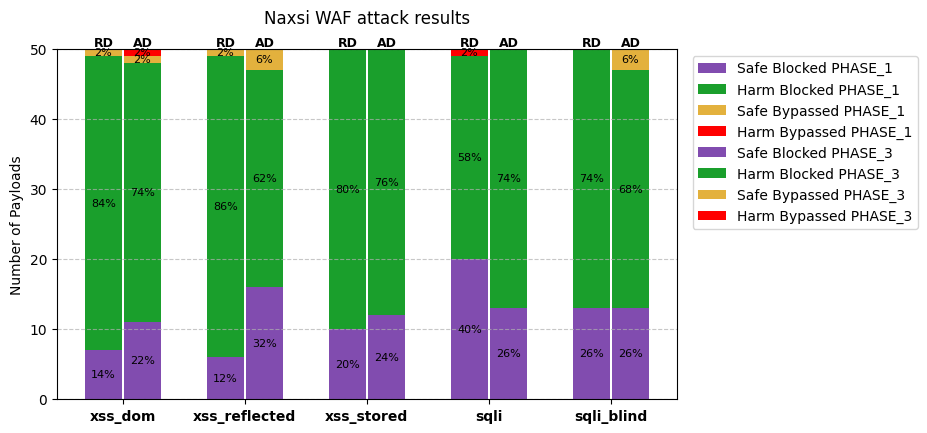

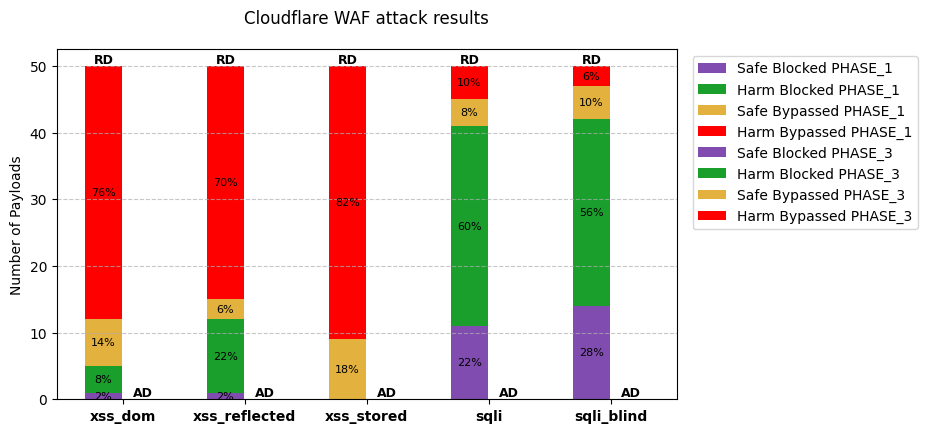

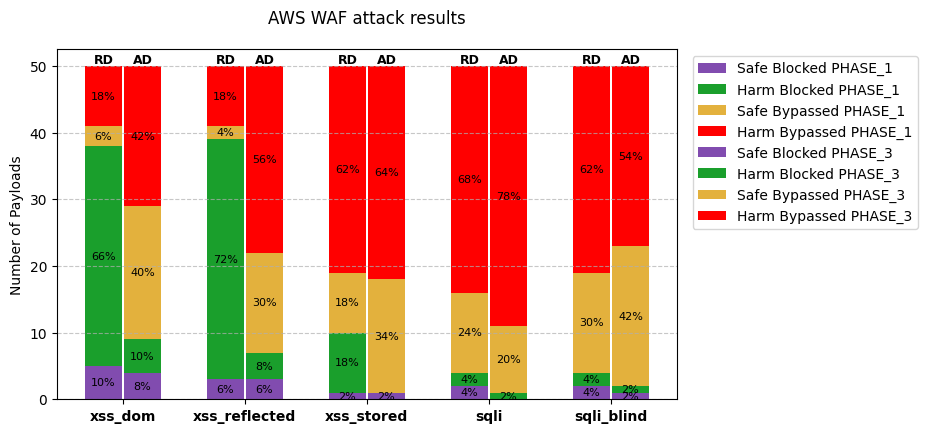

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Lọc chỉ lấy phase 1 và phase 3
phases = ['PHASE_1', 'PHASE_3']
attack_types = df['Attack Type'].unique()
wafs = df['WAF'].unique()

for waf in wafs:
    waf_df = df[df['WAF'] == waf]
    x = np.arange(len(attack_types))
    width = 0.30  # mỗi phase một nửa cột
    
    bars_phase = {}
    for phase in phases:
        safe_blocked = []
        harm_blocked = []
        safe_bypassed = []
        harm_bypassed = []
        total_payloads = []
        for attack in attack_types:
            row = waf_df[(waf_df['Attack Type'] == attack) & (waf_df['Phase'] == phase)]
            def extract_count(val):
                if isinstance(val, str) and '(' in val:
                    return int(val.split('(')[0].strip())
                try:
                    return int(val)
                except:
                    return 0
            safe_blocked.append(extract_count(row['blocked safe'].values[0]) if not row.empty else 0)
            harm_blocked.append(extract_count(row['blocked harm'].values[0]) if not row.empty else 0)
            safe_bypassed.append(extract_count(row['is_bypassed safe'].values[0]) if not row.empty else 0)
            harm_bypassed.append(extract_count(row['is_bypassed harm'].values[0]) if not row.empty else 0)
            total_payloads.append(extract_count(row['Total Payload'].values[0]) if not row.empty else 0)
        bars_phase[phase] = {
            'safe_blocked': safe_blocked,
            'harm_blocked': harm_blocked,
            'safe_bypassed': safe_bypassed,
            'harm_bypassed': harm_bypassed,
            'total_payloads': total_payloads
        }
    
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, phase in enumerate(phases):
        offset = -(width/2 + 0.01) if phase == 'PHASE_1' else (width/2 + 0.01)
        safe_blocked = np.array(bars_phase[phase]['safe_blocked'])
        harm_blocked = np.array(bars_phase[phase]['harm_blocked'])
        safe_bypassed = np.array(bars_phase[phase]['safe_bypassed'])
        harm_bypassed = np.array(bars_phase[phase]['harm_bypassed'])
        total_payloads = np.array(bars_phase[phase]['total_payloads'])
        
        alpha = 1
        colors = [
            ["#814CAF", '#814CAF'],
            ["#1A9F2C", "#1A9F2C"],
            ["#E3B13D", "#E3B13D"],
            ["#FF0000", "#FF0000"],
        ]
        p1 = ax.bar(x + offset, safe_blocked, width, label=f'Safe Blocked {phase}', color=colors[0][i], alpha=alpha)
        p2 = ax.bar(x + offset, harm_blocked, width, bottom=safe_blocked, label=f'Harm Blocked {phase}', color=colors[1][i], alpha=alpha)
        p3 = ax.bar(x + offset, safe_bypassed, width, bottom=safe_blocked+harm_blocked, label=f'Safe Bypassed {phase}', color=colors[2][i], alpha=alpha)
        p4 = ax.bar(x + offset, harm_bypassed, width, bottom=safe_blocked+harm_blocked+safe_bypassed, label=f'Harm Bypassed {phase}', color=colors[3][i], alpha=alpha)
        
        # Hiển thị phần trăm trên từng phần cột chồng
        for j in range(len(attack_types)):
            total = total_payloads[j] if total_payloads[j] > 0 else 1
            y_offset = 0
            for val in [safe_blocked[j], harm_blocked[j], safe_bypassed[j], harm_bypassed[j]]:
                if val > 0:
                    percent = val * 100 / total
                    ax.text(x[j] + offset, y_offset + val/2, f'{percent:.0f}%', ha='center', va='center', fontsize=8, color='black')
                y_offset += val
        # Hiển thị chữ Phase1/Phase3 trên đầu mỗi cột con
        for j in range(len(attack_types)):
            text = "RD" if phase == 'PHASE_1' else "AD"
            max_height = safe_blocked[j] + harm_blocked[j] + safe_bypassed[j] + harm_bypassed[j]
            ax.text(x[j] + offset, max_height , text, ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')
    
    ax.set_ylabel('Number of Payloads')
    ax.set_title(f'{waf} WAF attack results', y=1.05)
    ax.set_xticks(x)
    ax.set_xticklabels([attack_type.replace("sql_injection", "sqli") for attack_type in attack_types], rotation=0, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.subplots_adjust(bottom=0.18)
    fig.align_xlabels()
    plt.show()


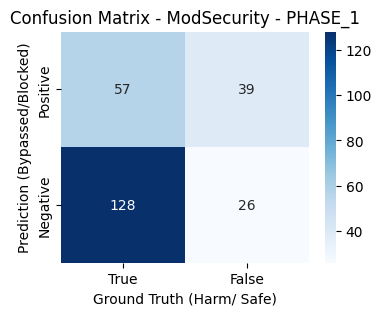

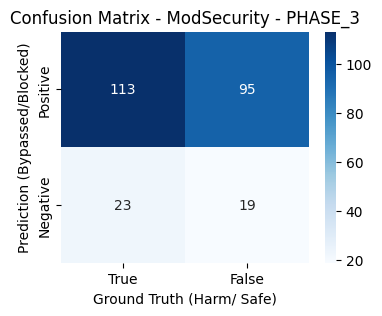

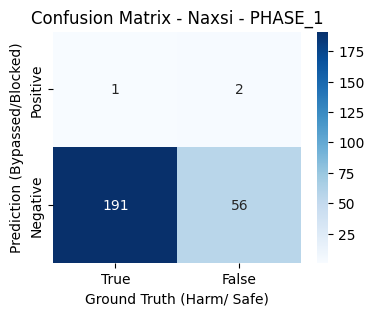

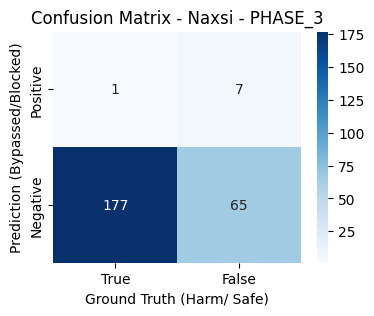

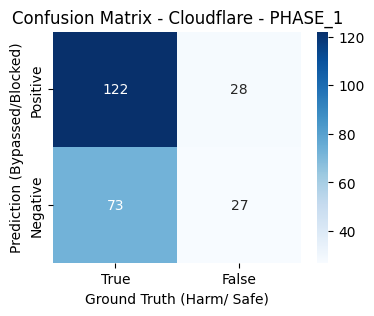

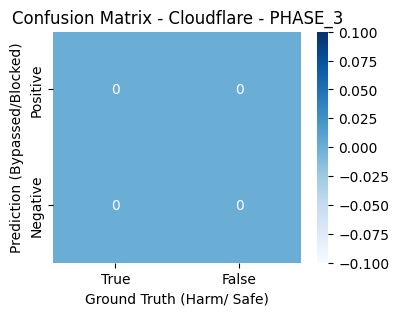

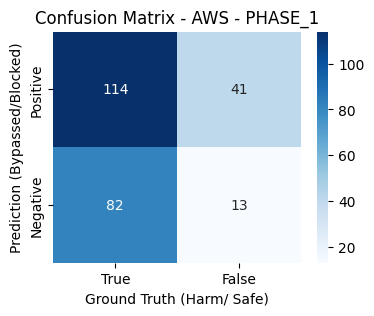

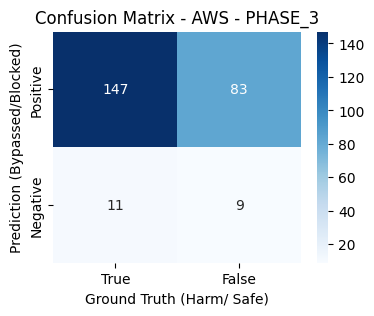

,WAF,Attack Type,Phase,Precision,Recall,F2
0,ModSecurity,xss_dom,PHASE_1,0.555556,0.125000,0.147929
1,ModSecurity,xss_dom,PHASE_3,0.514286,0.782609,0.708661
2,ModSecurity,xss_reflected,PHASE_1,0.428571,0.081081,0.096774
3,ModSecurity,xss_reflected,PHASE_3,0.619048,0.838710,0.783133
4,ModSecurity,xss_stored,PHASE_1,0.815789,0.720930,0.738095
5,ModSecurity,xss_stored,PHASE_3,0.613636,1.000000,0.888158
6,ModSecurity,sql_injection,PHASE_1,0.611111,0.289474,0.323529
7,ModSecurity,sql_injection,PHASE_3,0.577778,0.838710,0.769231
8,ModSecurity,sql_injection_blind,PHASE_1,0.291667,0.259259,0.265152
9,ModSecurity,sql_injection_blind,PHASE_3,0.380952,0.666667,0.579710


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, fbeta_score

# Tạo ma trận confusion P/N - T/F cho từng WAF, Attack Type, Phase
results = []
for waf in df['WAF'].unique():
    for attack_type in df['Attack Type'].unique():
        for phase in df['Phase'].unique():
            row = df[(df['WAF'] == waf) & (df['Attack Type'] == attack_type) & (df['Phase'] == phase)]
            if row.empty:
                continue
            # Lấy số lượng
            tp = int(row['is_bypassed harm'].values[0].split('(')[0]) if isinstance(row['is_bypassed harm'].values[0], str) and '(' in row['is_bypassed harm'].values[0] else int(row['is_bypassed harm'].values[0])
            fp = int(row['is_bypassed safe'].values[0].split('(')[0]) if isinstance(row['is_bypassed safe'].values[0], str) and '(' in row['is_bypassed safe'].values[0] else int(row['is_bypassed safe'].values[0])
            fn = int(row['blocked harm'].values[0].split('(')[0]) if isinstance(row['blocked harm'].values[0], str) and '(' in row['blocked harm'].values[0] else int(row['blocked harm'].values[0])
            tn = int(row['blocked safe'].values[0].split('(')[0]) if isinstance(row['blocked safe'].values[0], str) and '(' in row['blocked safe'].values[0] else int(row['blocked safe'].values[0])
            results.append({
                'WAF': waf,
                'Attack Type': attack_type,
                'Phase': phase,
                'TP': tp,
                'FP': fp,
                'FN': fn,
                'TN': tn
            })

conf_df = pd.DataFrame(results)

# Hiển thị bản đồ nhiệt cho từng WAF
for waf in conf_df['WAF'].unique():
    for phase in conf_df['Phase'].unique():
        sub = conf_df[(conf_df['WAF'] == waf) & (conf_df['Phase'] == phase)]
        if sub.empty:
            continue
        matrix = np.zeros((2,2), dtype=int)
        # Sắp xếp: [[TP, FP], [FN, TN]]
        matrix[0,0] = sub['TP'].sum()
        matrix[0,1] = sub['FP'].sum()
        matrix[1,0] = sub['FN'].sum()
        matrix[1,1] = sub['TN'].sum()
        plt.figure(figsize=(4,3))
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['True', 'False'], yticklabels=['Positive', 'Negative'])
        plt.title(f'Confusion Matrix - {waf} - {phase}')
        plt.xlabel('Ground Truth (Harm/ Safe)')
        plt.ylabel('Prediction (Bypassed/Blocked)')
        plt.show()

# Tính các chỉ số ML cho từng WAF, Attack Type, Phase
metrics = []
for i, row in conf_df.iterrows():
    TP, FP, FN, TN = row['TP'], row['FP'], row['FN'], row['TN']
    y_true = [1]*TP + [0]*FP + [1]*FN + [0]*TN
    y_pred = [1]*TP + [1]*FP + [0]*FN + [0]*TN
    if len(y_true) == 0:
        continue
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    metrics.append({
        'WAF': row['WAF'],
        'Attack Type': row['Attack Type'],
        'Phase': row['Phase'],
        'Precision': precision,
        'Recall': recall,
        'F2': f2
    })
metrics_df = pd.DataFrame(metrics)
metrics_df